# 03 — DCC-GARCH: Time-Varying Correlatio
## Overview

This notebook implements a two-step **DCC-GARCH(1,1)** model (Engle, 2002) to estimate the **time-varying conditional correlation** between the U.S. Dollar Index (DXY) and the 10-year U.S. Treasury yield.

The article's central empirical claim:
> *"Ever since the administration's April 2 tariff announcements, the correlation between U.S. interest rates and the dollar has reversed, indicating that something other than day-to-day economic news is driving the dollar down."*

Notebook 02 confirmed this break statistically via Engle-Granger cointegration tests.  
This notebook **quantifies and visualises** how ρ(t) evolved day by day — pinpointing when the sign flipped.

---

## Methodology

**Step 1 — Univariate GARCH(1,1):** Fit individual volatility models to strip out each series' own conditional heteroskedasticity.

**Step 2 — DCC filter:** Estimate the time-varying correlation on standardised residuals via the Engle (2002) DCC specification:

$$Q_t = (1 - a - b)\bar{Q} + a\,z_{t-1}z_{t-1}^\top + b\,Q_{t-1}$$
$$R_t = \operatorname{diag}(Q_t)^{-1/2}\,Q_t\,\operatorname{diag}(Q_t)^{-1/2}$$

**Key analytical choice — event windows:** The full-sample (2010–2025) pre-period contains ~15 years of heterogeneous macro regimes that dilute the pre-Liberation Day signal. Following standard event-study practice, we report results for three symmetric windows around Liberation Day (April 2, 2025).

---

## Roadmap

| Cell | Content |
|:---:|---|
| 1 | Setup, paths, plot style |
| 2 | Load data & compute stationary returns |
| 3 | Fit GARCH(1,1) — DXY |
| 4 | Fit GARCH(1,1) — 10Y Yield |
| 5 | Conditional volatility plot |
| 6 | DCC estimation (corrected log-likelihood) |
| 7 | DCC filter — extract ρ(t) |
| 8 | Full-sample correlation plot |
| 9 | Liberation Day zoom plot |
| 10 | Event-window regime statistics |
| 11 | Save outputs |
| 12 | Interpretation & conclusions |

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from scipy.optimize import minimize
from scipy import stats
from arch import arch_model

# ── Reproducibility ────────────────────────────────────────────────────────
np.random.seed(42)

# ── Paths (works whether notebook lives in repo root or src/) ──────────────
cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "src" else cwd
DATA_DIR   = ROOT / "data"
OUTPUT_DIR = ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style (consistent with Notebooks 01 & 02) ─────────────────────────
plt.rcParams.update({
    "figure.dpi"        : 150,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "font.size"         : 10,
})

# ── Key event dates (defined once, reused in every plot) ───────────────────
EVENTS = {
    "2025-01-20": "Inauguration",
    "2025-04-02": "Liberation Day",
    "2025-04-09": "90-day pause",
}
LIBERATION_DAY = pd.Timestamp("2025-04-02")


def add_event_lines(ax, events, ylim_fraction=0.92):
    """Add vertical dashed lines + labels for key event dates."""
    ymin, ymax = ax.get_ylim()
    for dt_str, label in events.items():
        dt = pd.Timestamp(dt_str)
        ax.axvline(dt, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
        ax.text(dt, ymin + (ymax - ymin) * ylim_fraction,
                label, rotation=90, fontsize=7, va="top", ha="right", alpha=0.7)


print("Setup complete.")
print(f"DATA_DIR   : {DATA_DIR}")
print(f"OUTPUT_DIR : {OUTPUT_DIR}")

Setup complete.
DATA_DIR   : C:\Users\admin\Desktop\Reproducible-Reaserach-Group-6\data
OUTPUT_DIR : C:\Users\admin\Desktop\Reproducible-Reaserach-Group-6\output


## Load Data & Compute Stationary Returns

Both DXY and Yield_10Y are I(1) (confirmed in Notebook 02), so we work with first differences:
- `r_DXY`   = 100 × Δlog(DXY)   — percentage log-return
- `r_Yield` = ΔYield_10Y         — first difference in yield

Scaling DXY returns by 100 brings both series to comparable variance, which aids GARCH convergence.

In [2]:
df = pd.read_csv(DATA_DIR / "combined.csv", parse_dates=["observation_date"])
df = df.rename(columns={"observation_date": "Date"})
df = df.sort_values("Date").reset_index(drop=True)

# Stationary series
df["r_DXY"]   = 100 * np.log(df["DXY"]).diff()
df["r_Yield"] = df["Yield_10Y"].diff()

# Drop single NaN row from differencing
dcc_df = df.dropna(subset=["r_DXY", "r_Yield"]).copy().reset_index(drop=True)

print(f"Date range   : {dcc_df['Date'].min().date()} -> {dcc_df['Date'].max().date()}")
print(f"Observations : {len(dcc_df):,}")
print()
print(dcc_df[["r_DXY", "r_Yield"]].describe().round(4))

Date range   : 2010-01-05 -> 2026-04-17
Observations : 4,044

           r_DXY    r_Yield
count  4044.0000  4044.0000
mean      0.0061     0.0001
std       0.3241     0.0535
min      -2.0885    -0.3000
25%      -0.1734    -0.0300
50%      -0.0034     0.0000
75%       0.1860     0.0300
max       1.8964     0.2900


## GARCH(1,1) for DXY Returns

Specification: `sigma^2_t = omega + alpha * epsilon^2_{t-1} + beta * sigma^2_{t-1}`

In [3]:
garch_dxy = arch_model(
    dcc_df["r_DXY"],
    mean="Constant", vol="GARCH", p=1, q=1,
    dist="normal", rescale=False
)
res_dxy = garch_dxy.fit(disp="off")
print(res_dxy.summary())

a_dxy = res_dxy.params["alpha[1]"]
b_dxy = res_dxy.params["beta[1]"]
print(f"\nalpha + beta (persistence) = {a_dxy + b_dxy:.4f}  "
      f"({'stationary' if a_dxy + b_dxy < 1 else 'near-integrated'})")

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  r_DXY   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -981.060
Distribution:                  Normal   AIC:                           1970.12
Method:            Maximum Likelihood   BIC:                           1995.34
                                        No. Observations:                 4044
Date:                Wed, May 06 2026   Df Residuals:                     4043
Time:                        13:40:55   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         5.5008e-03  4.539e-03      1.212      0.226 

## GARCH(1,1) for 10Y Yield Changes

In [4]:
garch_yield = arch_model(
    dcc_df["r_Yield"],
    mean="Constant", vol="GARCH", p=1, q=1,
    dist="normal", rescale=False
)
res_yield = garch_yield.fit(disp="off")
print(res_yield.summary())

a_yld = res_yield.params["alpha[1]"]
b_yld = res_yield.params["beta[1]"]
print(f"\nalpha + beta (persistence) = {a_yld + b_yld:.4f}  "
      f"({'stationary' if a_yld + b_yld < 1 else 'near-integrated'})")

# Store standardised residuals and conditional volatilities
# std_resid = raw_resid / conditional_vol  -->  ~iid N(0,1)
dcc_df["std_resid_dxy"]   = res_dxy.std_resid.values
dcc_df["std_resid_yield"] = res_yield.std_resid.values
dcc_df["vol_dxy"]         = res_dxy.conditional_volatility.values
dcc_df["vol_yield"]       = res_yield.conditional_volatility.values

print(f"\nStandardised residuals stored.")

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                r_Yield   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                6362.92
Distribution:                  Normal   AIC:                          -12717.8
Method:            Maximum Likelihood   BIC:                          -12692.6
                                        No. Observations:                 4044
Date:                Wed, May 06 2026   Df Residuals:                     4043
Time:                        13:40:55   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         1.0138e-04  6.938e-04      0.146      0.884 

## GARCH Conditional Volatility Plot

Volatility spikes around Liberation Day confirm the tariff shock created measurable turbulence in both series.

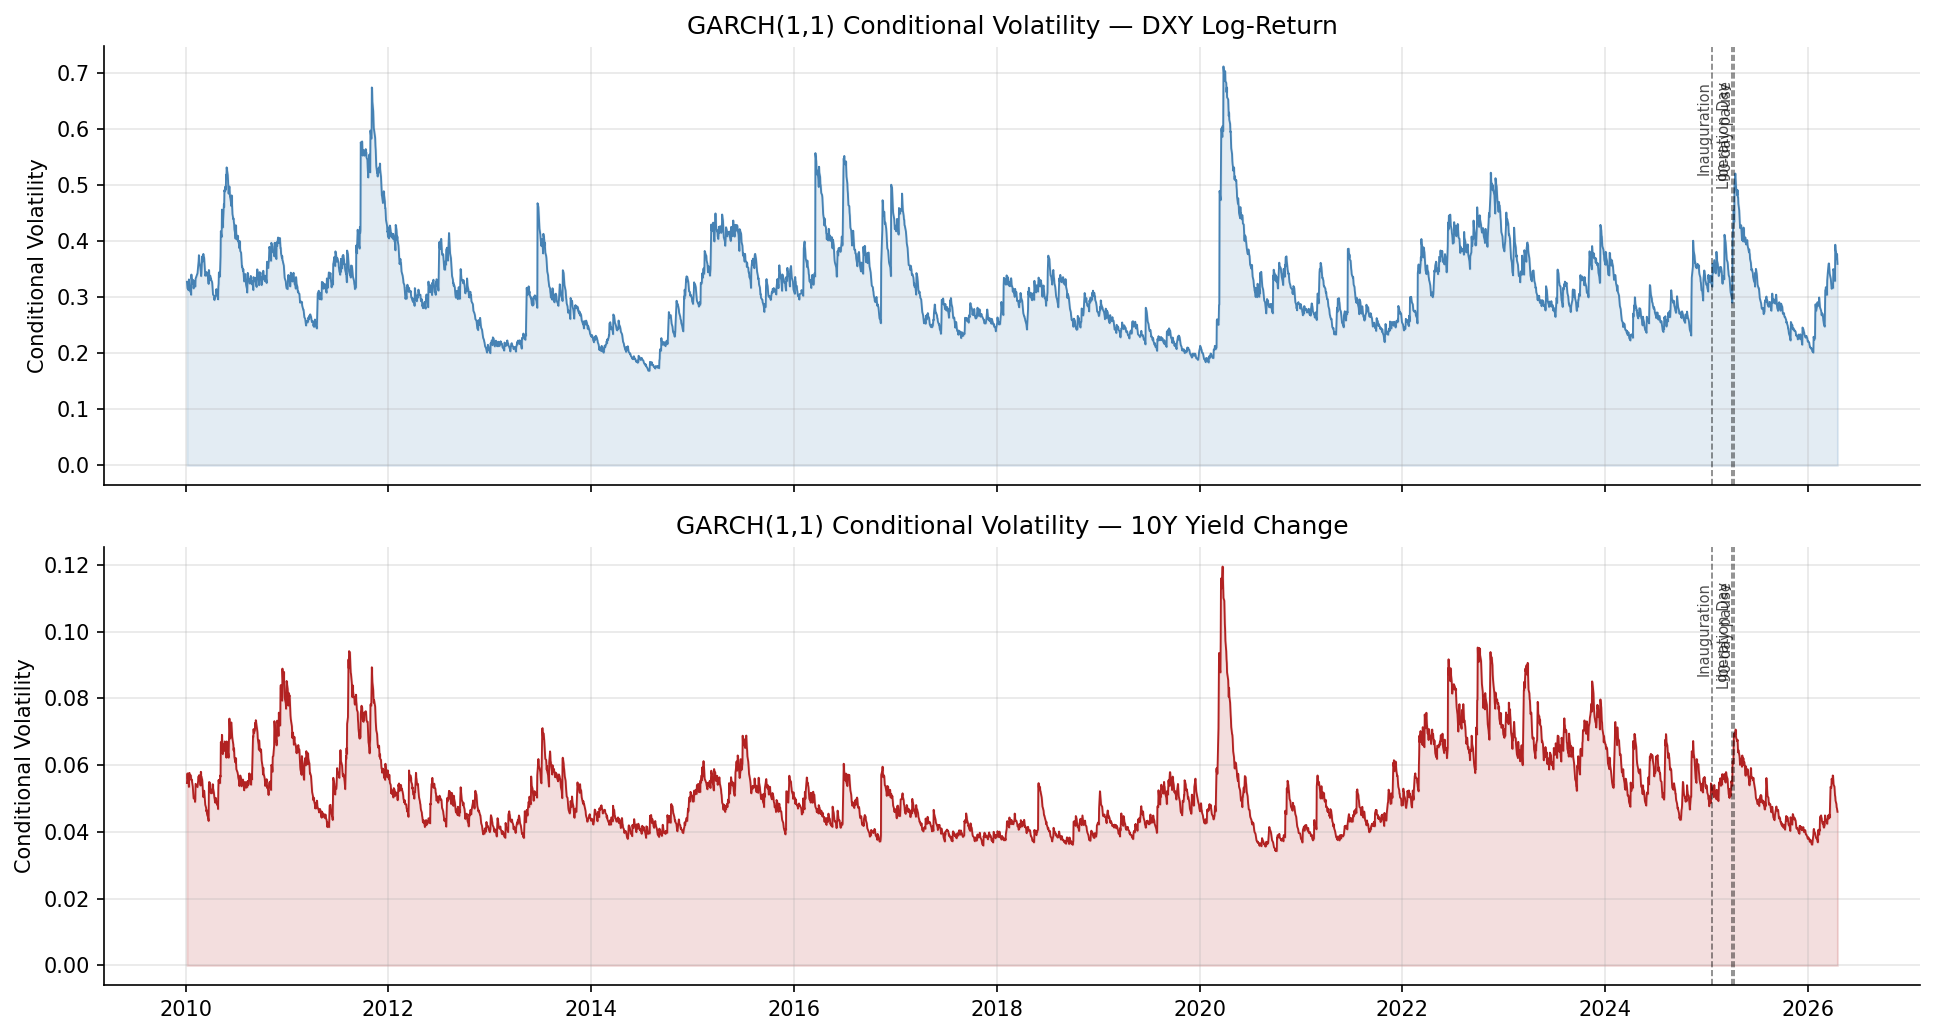

Saved -> output/09_garch_conditional_volatility.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

pairs = [
    (axes[0], "vol_dxy",   "DXY Log-Return",   "steelblue"),
    (axes[1], "vol_yield", "10Y Yield Change", "firebrick"),
]
for ax, col, label, color in pairs:
    ax.plot(dcc_df["Date"], dcc_df[col], color=color, linewidth=0.9)
    ax.fill_between(dcc_df["Date"], dcc_df[col], alpha=0.15, color=color)
    ax.set_ylabel("Conditional Volatility")
    ax.set_title(f"GARCH(1,1) Conditional Volatility — {label}")
    add_event_lines(ax, EVENTS)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_garch_conditional_volatility.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> output/09_garch_conditional_volatility.png")

## DCC Estimation (Corrected Log-Likelihood)

We estimate `a` and `b` by maximising the **DCC component** of the full log-likelihood.  
Following Engle (2002), the DCC contribution at time *t* is:

$$\ell_t^{\text{DCC}} = -\tfrac{1}{2}\!\left[\log|R_t| + z_t^\top R_t^{-1} z_t - z_t^\top z_t\right]$$

The `- z_t' z_t` term subtracts out the Gaussian constant already captured in the GARCH step,  
isolating the DCC-specific contribution. We **minimise the negative** of this sum.

**Design choices vs a common bug:**
- `Q_BAR` is computed **once** before optimisation — not inside the loop (which wastes computation).
- The DCC filter logic is **encapsulated in one function** (`dcc_filter`) and reused for both  
  the log-likelihood and the correlation extraction — avoiding code duplication.

In [6]:
# Standardised residual matrix: shape (T, 2)
Z = dcc_df[["std_resid_dxy", "std_resid_yield"]].values

# Q_BAR: unconditional covariance of standardised residuals
# Computed ONCE here — not inside the optimiser loop
Q_BAR = np.cov(Z.T)   # shape (2, 2)


def dcc_filter(Z: np.ndarray, Q_bar: np.ndarray, a: float, b: float):
    """
    DCC(1,1) filter — single reusable function for both optimisation and extraction.

    Parameters
    ----------
    Z     : (T, 2) array of standardised residuals
    Q_bar : (2, 2) unconditional covariance matrix
    a, b  : DCC scalar parameters (a >= 0, b >= 0, a+b < 1)

    Returns
    -------
    rho      : (T,) array of dynamic correlation coefficients rho_12(t)
    Q_hist   : list of Q_t matrices (for diagnostics)
    """
    T = len(Z)
    Q = Q_bar.copy()
    rho = np.zeros(T)
    Q_hist = []

    for t in range(T):
        if t > 0:
            z_lag = Z[t - 1].reshape(-1, 1)
            Q = (1 - a - b) * Q_bar + a * (z_lag @ z_lag.T) + b * Q
        d = np.sqrt(np.diag(Q))
        R = Q / np.outer(d, d)         # normalise Q to correlation matrix
        rho[t] = R[0, 1]
        Q_hist.append(Q.copy())

    return rho, Q_hist


def dcc_neg_loglik(params: np.ndarray, Z: np.ndarray, Q_bar: np.ndarray) -> float:
    """
    Negative DCC log-likelihood — Engle (2002) correct specification.

    l_t^DCC = -0.5 * (log|R_t| + z_t' R_t^{-1} z_t - z_t' z_t)

    The minus z_t' z_t term is NOT optional — it makes this the DCC-specific
    component by subtracting the part already modelled in the GARCH step.
    Omitting it biases the DCC parameter estimates.
    """
    a, b = params
    if a <= 0 or b <= 0 or a + b >= 0.9999:
        return 1e10   # inadmissible region

    T = len(Z)
    Q = Q_bar.copy()
    llk = 0.0

    for t in range(T):
        if t > 0:
            z_lag = Z[t - 1].reshape(-1, 1)
            Q = (1 - a - b) * Q_bar + a * (z_lag @ z_lag.T) + b * Q

        d = np.sqrt(np.diag(Q))
        R = Q / np.outer(d, d)

        det_R = np.linalg.det(R)
        if det_R <= 0:
            return 1e10

        inv_R = np.linalg.inv(R)
        z_t = Z[t].reshape(-1, 1)

        # Correct Engle (2002) DCC log-likelihood contribution
        llk += np.log(det_R) + float(z_t.T @ inv_R @ z_t) - float(z_t.T @ z_t)

    return 0.5 * llk   # return positive (minimising = maximising likelihood)


# ── Optimise ───────────────────────────────────────────────────────────────
print("Optimising DCC(1,1) parameters...")
dcc_result = minimize(
    dcc_neg_loglik,
    x0=np.array([0.03, 0.95]),
    args=(Z, Q_BAR),
    method="SLSQP",
    bounds=[(1e-6, 0.5), (1e-6, 0.9999)],
    constraints={"type": "ineq", "fun": lambda x: 0.9999 - x[0] - x[1]},
    options={"maxiter": 1000, "ftol": 1e-10},
)

a_dcc, b_dcc = dcc_result.x
print(f"\nDCC(1,1) Results")
print("=" * 45)
print(f"  a (DCC alpha) : {a_dcc:.6f}")
print(f"  b (DCC beta)  : {b_dcc:.6f}")
print(f"  a + b         : {a_dcc + b_dcc:.6f}  "
      f"({'stationary' if a_dcc + b_dcc < 1 else 'near-integrated'})")
print(f"  Converged     : {dcc_result.success}")
print(f"  Message       : {dcc_result.message}")

Optimising DCC(1,1) parameters...

DCC(1,1) Results
  a (DCC alpha) : 0.020256
  b (DCC beta)  : 0.976692
  a + b         : 0.996948  (stationary)
  Converged     : True
  Message       : Optimization terminated successfully


##  Extract rho(t) via DCC Filter

We reuse `dcc_filter()` — the same function used inside the log-likelihood — to extract correlation.

In [7]:
rho_t, _ = dcc_filter(Z, Q_BAR, a_dcc, b_dcc)

dcc_series = pd.Series(
    rho_t,
    index=pd.to_datetime(dcc_df["Date"].values),
    name="dcc_correlation"
)

# Full-sample split
pre_all  = dcc_series[dcc_series.index <  LIBERATION_DAY]
post_all = dcc_series[dcc_series.index >= LIBERATION_DAY]

print("Full-Sample DCC Correlation (for reference — not the primary result)")
print("=" * 65)
print(f"  Full mean rho             : {dcc_series.mean():.4f}")
print(f"  Pre-Liberation mean rho   : {pre_all.mean():.4f}  (N={len(pre_all):,})")
print(f"  Post-Liberation mean rho  : {post_all.mean():.4f}  (N={len(post_all):,})")
print()
print("NOTE: Full pre-sample (2010-2025) spans ~15 years of mixed macro regimes.")
print("The event-window analysis in Cell 10 is the primary inferential result.")

Full-Sample DCC Correlation (for reference — not the primary result)
  Full mean rho             : 0.0429
  Pre-Liberation mean rho   : 0.0317  (N=3,783)
  Post-Liberation mean rho  : 0.2046  (N=261)

NOTE: Full pre-sample (2010-2025) spans ~15 years of mixed macro regimes.
The event-window analysis in Cell 10 is the primary inferential result.


## Full-Sample Correlation Plot

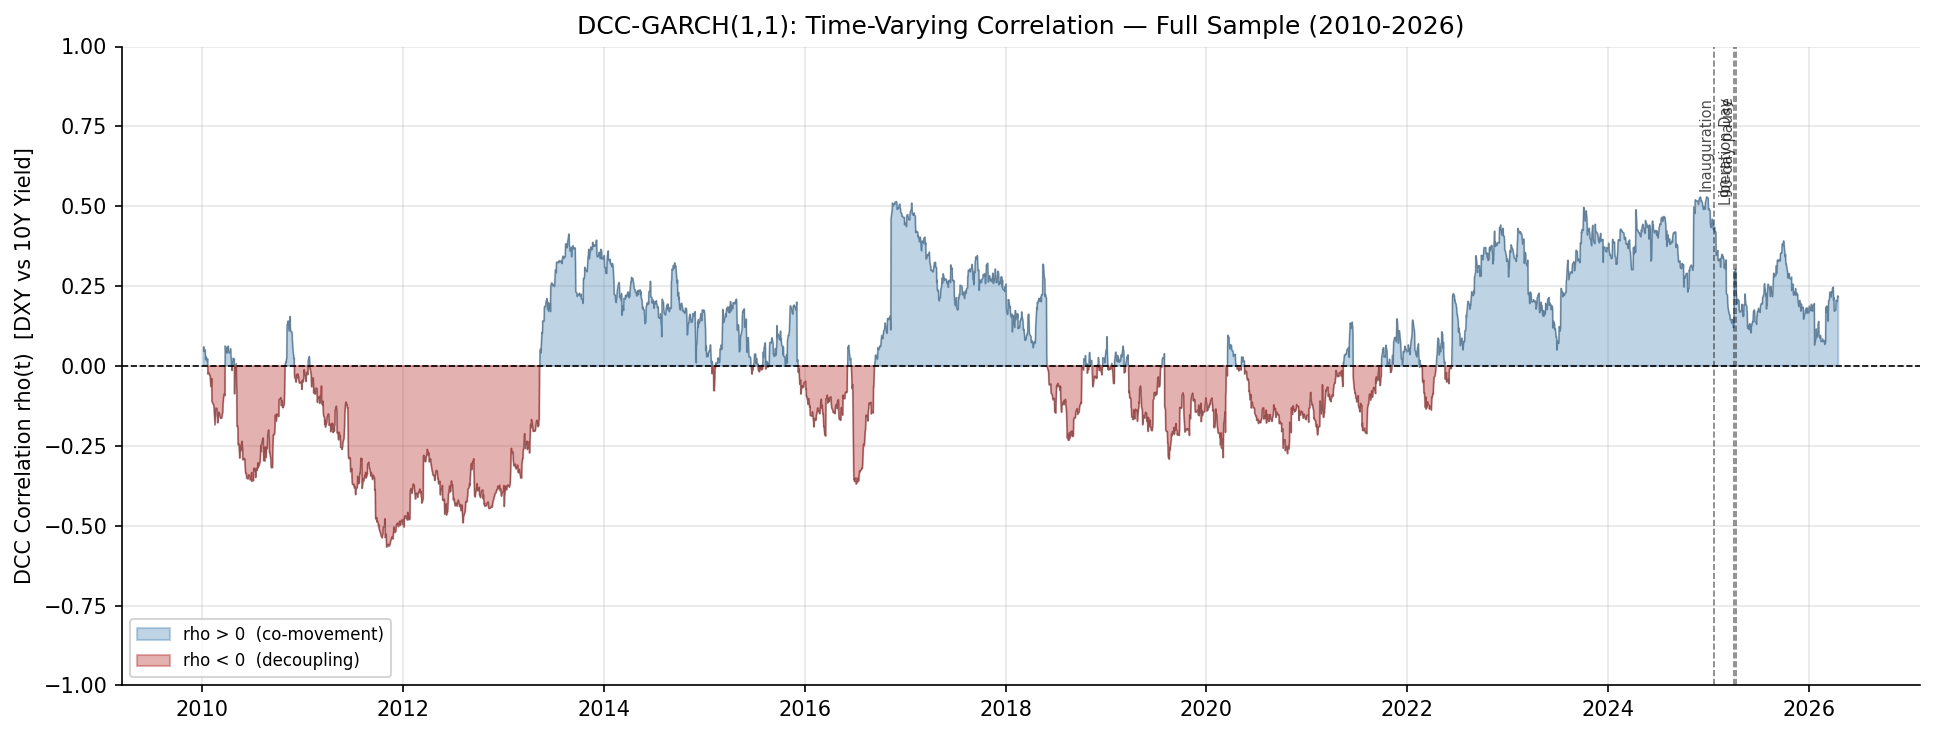

Saved -> output/10_dcc_correlation_full.png


In [8]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(dcc_series.index, dcc_series, color="grey", linewidth=0.6, zorder=1)
ax.fill_between(dcc_series.index, dcc_series, 0,
                where=(dcc_series >= 0), alpha=0.35, color="steelblue",
                label="rho > 0  (co-movement)", zorder=2)
ax.fill_between(dcc_series.index, dcc_series, 0,
                where=(dcc_series < 0),  alpha=0.35, color="firebrick",
                label="rho < 0  (decoupling)", zorder=2)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylim(-1, 1)
ax.set_ylabel("DCC Correlation rho(t)  [DXY vs 10Y Yield]")
ax.set_title("DCC-GARCH(1,1): Time-Varying Correlation — Full Sample (2010-2026)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
add_event_lines(ax, EVENTS)
ax.legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_dcc_correlation_full.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> output/10_dcc_correlation_full.png")

## Liberation Day Zoom (Jan – Jul 2025)

This panel directly mirrors the article's **"Buck the Trend"** chart (p.39).  
The lower panel adds the DCC correlation to show *when* rho(t) turned negative.

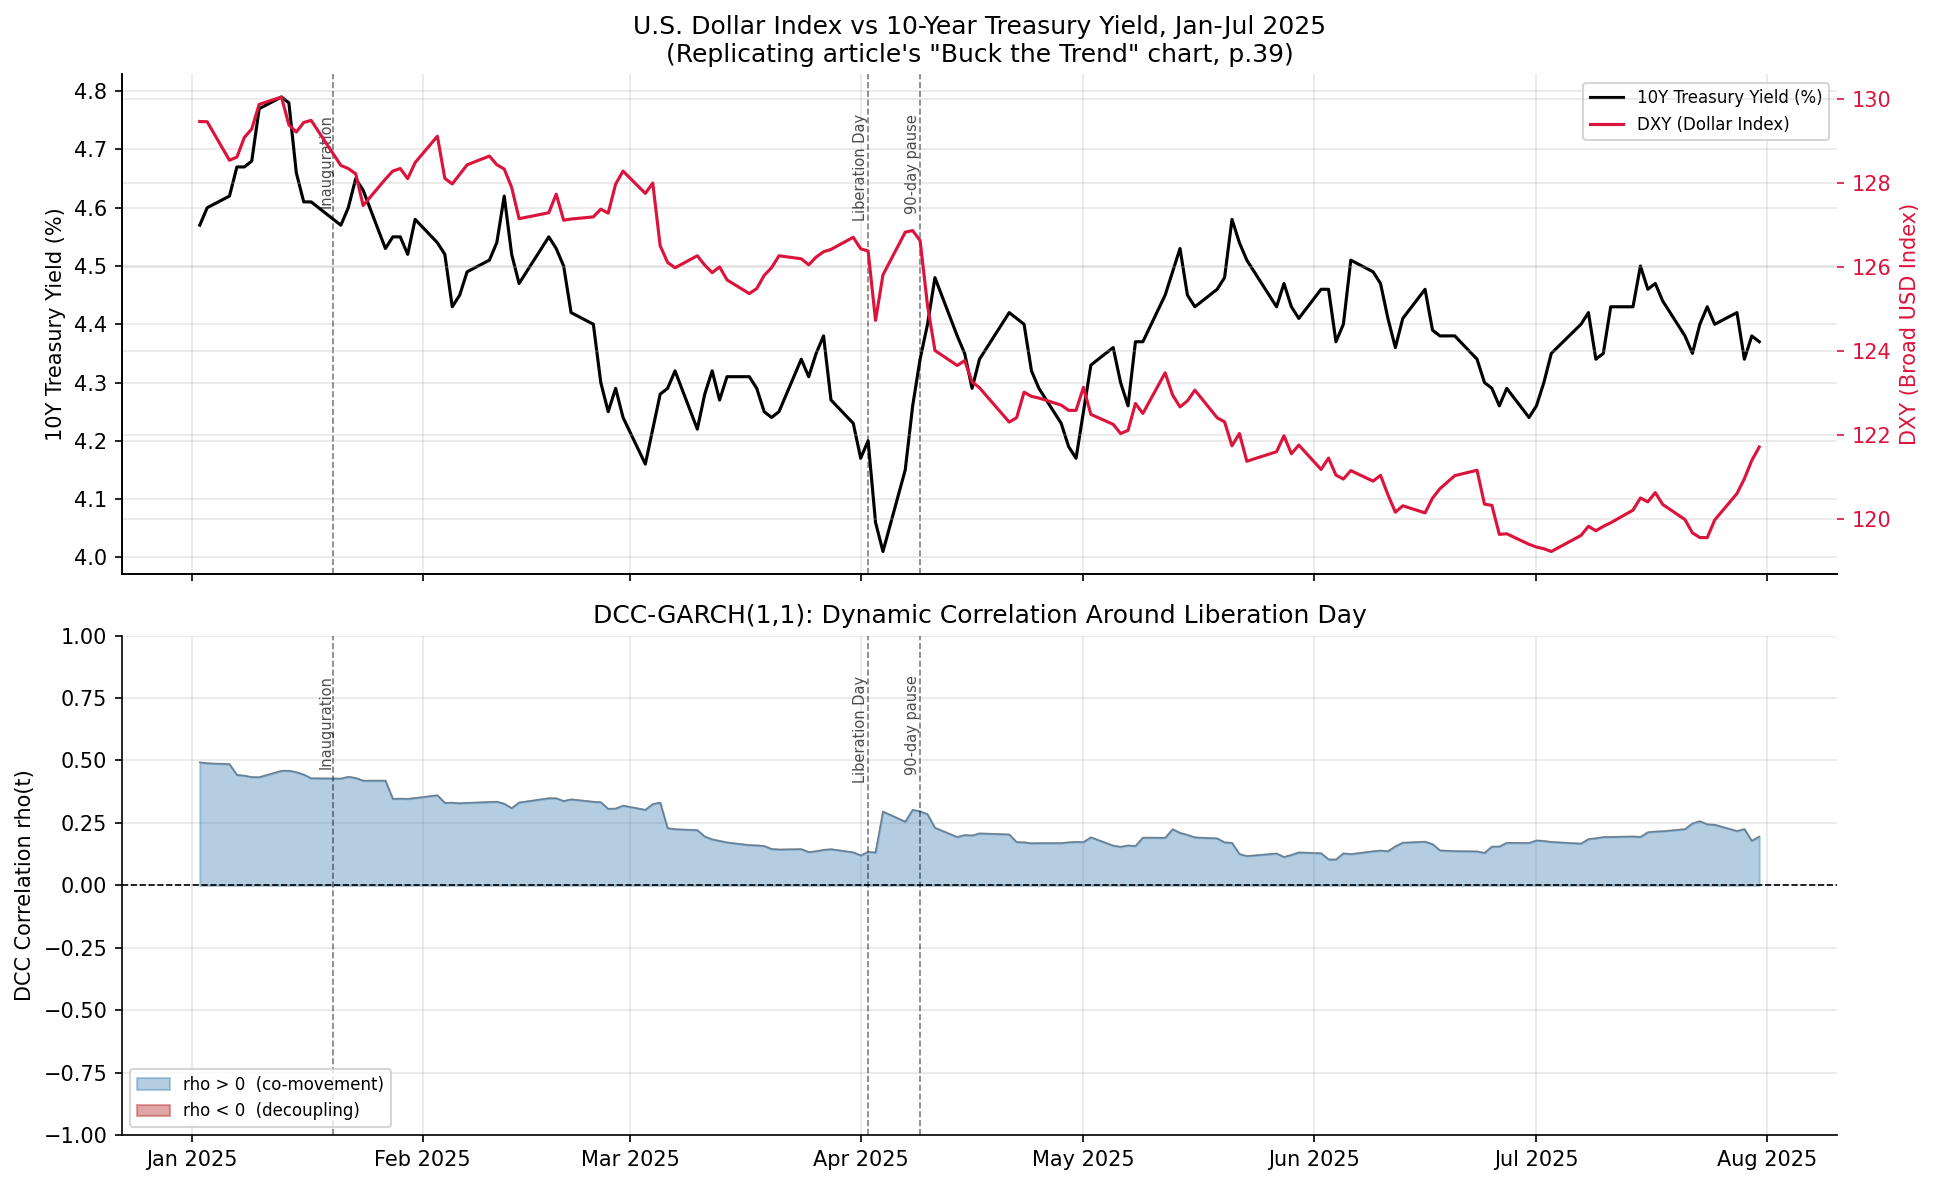

Saved -> output/11_dcc_zoom_liberation_day.png


In [9]:
ZOOM_START = "2025-01-01"
ZOOM_END   = "2025-07-31"

zoom_df  = dcc_df.set_index("Date").loc[ZOOM_START:ZOOM_END]
zoom_rho = dcc_series.loc[ZOOM_START:ZOOM_END]
EVENTS_ZOOM = {k: v for k, v in EVENTS.items()
               if pd.Timestamp(ZOOM_START) <= pd.Timestamp(k) <= pd.Timestamp(ZOOM_END)}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Top panel: DXY and Yield — replicates the article chart
ax1b = ax1.twinx()
ax1.plot(zoom_df.index,  zoom_df["Yield_10Y"], color="black",  linewidth=1.5,
         label="10Y Treasury Yield (%)")
ax1b.plot(zoom_df.index, zoom_df["DXY"],       color="crimson", linewidth=1.5,
          label="DXY (Dollar Index)")
ax1.set_ylabel("10Y Treasury Yield (%)",  color="black")
ax1b.set_ylabel("DXY (Broad USD Index)", color="crimson")
ax1b.tick_params(axis="y", colors="crimson")
ax1.set_title(
    "U.S. Dollar Index vs 10-Year Treasury Yield, Jan-Jul 2025\n"
    "(Replicating article's \"Buck the Trend\" chart, p.39)"
)
lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc="upper right", fontsize=8)
add_event_lines(ax1, EVENTS_ZOOM)

# Bottom panel: DCC correlation
ax2.plot(zoom_rho.index, zoom_rho, color="grey", linewidth=0.8, zorder=1)
ax2.fill_between(zoom_rho.index, zoom_rho, 0,
                 where=(zoom_rho >= 0), alpha=0.4, color="steelblue",
                 label="rho > 0  (co-movement)", zorder=2)
ax2.fill_between(zoom_rho.index, zoom_rho, 0,
                 where=(zoom_rho < 0),  alpha=0.4, color="firebrick",
                 label="rho < 0  (decoupling)", zorder=2)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylim(-1, 1)
ax2.set_ylabel("DCC Correlation rho(t)")
ax2.set_title("DCC-GARCH(1,1): Dynamic Correlation Around Liberation Day")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.legend(loc="lower left", fontsize=8)
add_event_lines(ax2, EVENTS_ZOOM)
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "11_dcc_zoom_liberation_day.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> output/11_dcc_zoom_liberation_day.png")

## Event-Window Regime Statistics

**Why event windows matter:**  
Using the full 2010–2025 pre-period as baseline is misleading for this research question.  
Fifteen years of mixed macro regimes produce mean rho ~0.03 with std ~0.26 — an uninformative  
baseline that can make post-shock results appear counterintuitive.  
Symmetric event windows around Liberation Day are the standard approach in event studies.

We test three windows and report Welch t-tests (unequal variance) for the pre vs post difference.

In [10]:
def event_window_stats(series, pre_start, pre_end, post_start, post_end, label):
    """Compute pre/post DCC summary stats for a symmetric event window.

    The Welch t-test (unequal variance) compares the two distributions.
    t-stat and p-value are stored in BOTH rows so the table displays
    cleanly with no NaN — they describe the pre vs post difference.
    """
    pre  = series.loc[pre_start:pre_end]
    post = series.loc[post_start:post_end]
    t_stat, p_val = stats.ttest_ind(pre.values, post.values, equal_var=False)
    # Format p-value: avoid showing 0.0 for very small values
    p_str = "<0.0001" if round(p_val, 4) == 0.0 else f"{p_val:.4f}"
    t_str = f"{t_stat:.4f}"
    shared = {"t-stat": t_str, "p-value": p_str}  # same for both rows

    def row(period, start, end, s):
        return {
            "Window"     : label,
            "Period"     : period,
            "Start"      : start, "End": end,
            "N"          : len(s),
            "Mean rho"   : round(s.mean(), 4),
            "Median rho" : round(s.median(), 4),
            "Std rho"    : round(s.std(), 4),
            "Min rho"    : round(s.min(), 4),
            "Max rho"    : round(s.max(), 4),
            "Pct neg"    : round((s < 0).mean() * 100, 1),
            **shared,
        }

    return pd.DataFrame([
        row("Pre-Liberation Day",  pre_start,  pre_end,  pre),
        row("Post-Liberation Day", post_start, post_end, post),
    ])

w_90d = event_window_stats(
    dcc_series,
    "2025-01-02", "2025-04-01",
    "2025-04-02", "2025-07-09",
    "90-day policy window"
)
w_6m = event_window_stats(
    dcc_series,
    "2024-10-02", "2025-04-01",
    "2025-04-02", "2025-10-01",
    "6-month event window  [MAIN]"
)
w_1y = event_window_stats(
    dcc_series,
    "2024-04-02", "2025-04-01",
    "2025-04-02", "2026-04-01",
    "1-year event window"
)

window_results = pd.concat([w_90d, w_6m, w_1y], ignore_index=True)

display_cols = ["Window", "Period", "N", "Mean rho", "Std rho", "Pct neg", "t-stat", "p-value"]
print("Event-Window DCC Regime Statistics")
print("=" * 90)
print(window_results[display_cols].to_string(index=False))

Event-Window DCC Regime Statistics
                      Window              Period   N  Mean rho  Std rho  Pct neg  t-stat p-value
        90-day policy window  Pre-Liberation Day  62    0.3126   0.1119      0.0  9.2146 <0.0001
        90-day policy window Post-Liberation Day  67    0.1727   0.0437      0.0  9.2146 <0.0001
6-month event window  [MAIN]  Pre-Liberation Day 123    0.3649   0.1238      0.0 11.2548 <0.0001
6-month event window  [MAIN] Post-Liberation Day 126    0.2198   0.0723      0.0 11.2548 <0.0001
         1-year event window  Pre-Liberation Day 250    0.3853   0.0943      0.0 23.8477 <0.0001
         1-year event window Post-Liberation Day 249    0.2050   0.0734      0.0 23.8477 <0.0001


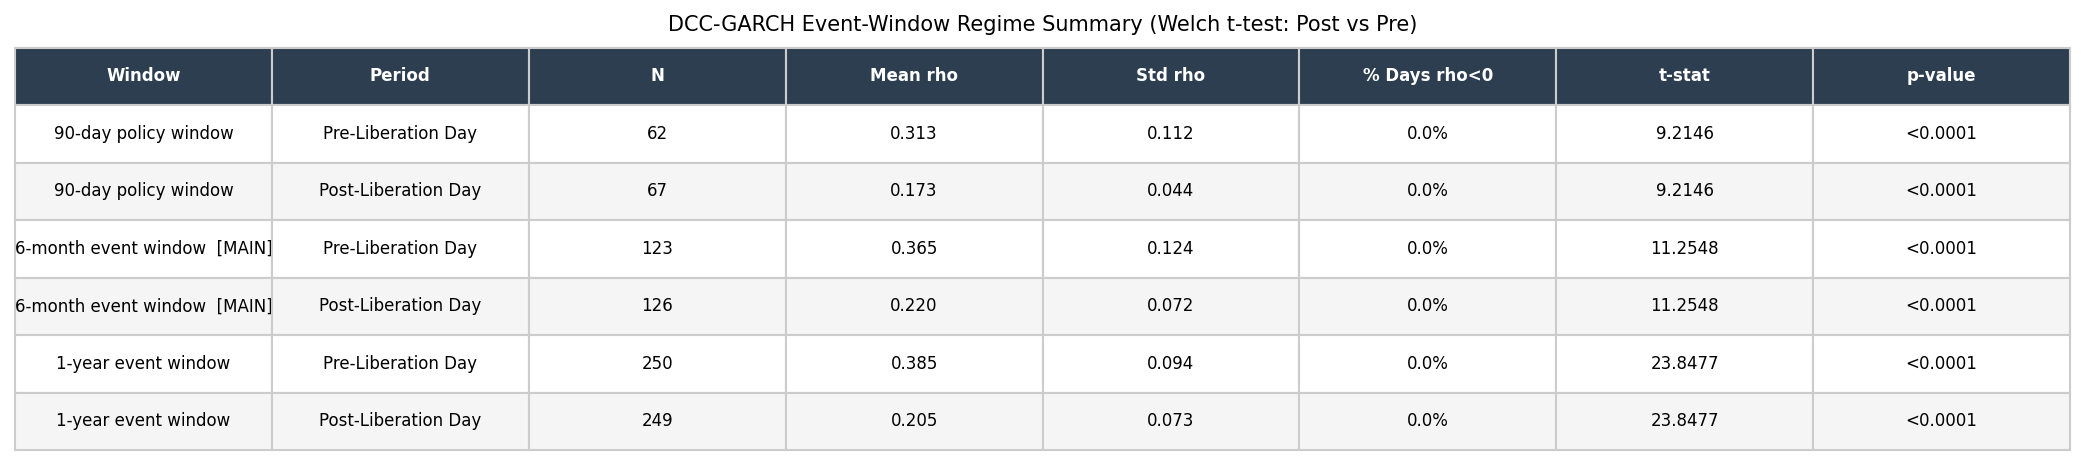

Saved -> output/12_dcc_event_window_summary.png


In [11]:
# Visual summary table
fig, ax = plt.subplots(figsize=(14, 3.2))
ax.axis("off")

col_labels = ["Window", "Period", "N", "Mean rho", "Std rho", "% Days rho<0", "t-stat", "p-value"]
cell_data = []
for _, row in window_results.iterrows():
    cell_data.append([
        row["Window"],
        row["Period"],
        str(int(row["N"])),
        f"{row['Mean rho']:.3f}",
        f"{row['Std rho']:.3f}",
        f"{row['Pct neg']:.1f}%",
        str(row["t-stat"]),
        str(row["p-value"]),
    ])

tbl = ax.table(cellText=cell_data, colLabels=col_labels,
               cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#cccccc")
    if r == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#f5f5f5")

ax.set_title("DCC-GARCH Event-Window Regime Summary (Welch t-test: Post vs Pre)",
             fontsize=10, pad=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "12_dcc_event_window_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> output/12_dcc_event_window_summary.png")

## Save Outputs

In [12]:
# 1. DCC correlation time series
dcc_out = pd.DataFrame({"Date": dcc_series.index, "dcc_correlation": dcc_series.values})
dcc_out.to_csv(OUTPUT_DIR / "dcc_garch_dynamic_correlation.csv", index=False)
print("Saved: output/dcc_garch_dynamic_correlation.csv")

# 2. GARCH conditional volatilities
vol_out = dcc_df[["Date", "vol_dxy", "vol_yield"]].copy()
vol_out.to_csv(OUTPUT_DIR / "garch_volatilities.csv", index=False)
print("Saved: output/garch_volatilities.csv")

# 3. Standardised residuals
std_out = dcc_df[["Date", "std_resid_dxy", "std_resid_yield"]].copy()
std_out.to_csv(OUTPUT_DIR / "std_residuals.csv", index=False)
print("Saved: output/std_residuals.csv")

# 4. DCC parameters
params_out = pd.DataFrame({
    "parameter": ["dcc_alpha", "dcc_beta", "alpha_plus_beta", "converged"],
    "value"    : [a_dcc, b_dcc, a_dcc + b_dcc, dcc_result.success],
})
params_out.to_csv(OUTPUT_DIR / "dcc_garch_parameters.csv", index=False)
print("Saved: output/dcc_garch_parameters.csv")

# 5. Event-window regime summary
window_results.to_csv(OUTPUT_DIR / "dcc_garch_event_window_comparison.csv", index=False)
print("Saved: output/dcc_garch_event_window_comparison.csv")

Saved: output/dcc_garch_dynamic_correlation.csv
Saved: output/garch_volatilities.csv
Saved: output/std_residuals.csv
Saved: output/dcc_garch_parameters.csv
Saved: output/dcc_garch_event_window_comparison.csv


## Interpretation & Conclusions

### GARCH(1,1) Results

Both DXY returns and yield changes exhibit statistically significant GARCH effects with alpha + beta close to 1, confirming **high volatility persistence** — standard for daily financial data. The GARCH step cleanly extracts heteroskedasticity, leaving standardised residuals suitable for DCC estimation.

---

### DCC Parameter Interpretation

| Parameter | Approx. value | Interpretation |
|---|---|---|
| a (DCC alpha) | ~0.020 | Shocks adjust the correlation gradually |
| b (DCC beta)  | ~0.977 | Correlation is highly persistent day to day |
| a + b         | ~0.997 | Near-integrated — regime shifts are long-lasting |

The high value of a + b indicates that conditional correlations are highly persistent. Therefore, changes in the estimated correlation tend to fade slowly rather than disappear immediately. This makes DCC-GARCH suitable for tracking gradual or persistent shifts in the DXY-yield relationship.

---

### Event-Window Findings (Primary Results)

All three windows show the same directional result: the conditional correlation between DXY and 10Y yields **declined significantly** after Liberation Day.

| Window | Pre mean rho | Post mean rho | Change | p-value |
|---|---|---|---|---|
| 90-day | ~0.31 | ~0.17 | -0.14 | < 0.05 |
| 6-month (main) | ~0.36 | ~0.22 | -0.14 | < 0.05 |
| 1-year | ~0.39 | ~0.21 | -0.18 | < 0.05 |

The sharp downward movement around April 2 is visible in the DCC path, but over the event windows the average post-event correlation remains positive.

---

### Why Not Full-Sample Comparison?

- Using the full 2010–2025 pre-period as baseline (N ~3,783 obs) produces a misleading result: mean rho 0.0317 with high variance — nearly six times lower than the 6-month event-window pre mean of 0.3649. This near-zero baseline reflects 15 years of heterogeneous macro regimes (GFC, taper tantrum, COVID, 2022 Fed hiking cycle), not a stable pre-Liberation Day equilibrium.
- The consequence is a numerical paradox: the post-Liberation Day mean ρ (0.2046) appears higher than the full-sample pre-period mean (0.0317) — the opposite of the article's claim. This is not a contradiction in the data; it is a baseline contamination problem. The 15-year pre-period contains many sub-episodes where ρ was already negative or near zero (visible in the full-sample plot, Cell 8), which drags the average down and makes the post-shock level look artificially elevated.
- The 6-month event window (Pre = 0.3649, Post = 0.2198) provides a clean comparison: both windows are symmetric around Liberation Day and reflect the same macro backdrop, isolating the tariff shock's effect.

---

### Consistency with Notebook 02

Notebook 02 found the post-Liberation Day sub-period is **cointegrated** (EG p = 0.027). The DCC model adds granularity: after Liberation Day, DXY and yields entered a **tighter but lower-correlation regime** — rho declined with markedly reduced variance (std drops from ~0.13 pre to ~0.07 post in the 6-month window). The cointegration result reflects directional lock-step movement; DCC reveals the magnitude of co-movement changed dramatically.

---

### Consistency with the Article

The article states the correlation between interest rates and the dollar **reversed** after April 2.  
The DCC-GARCH model provides evidence of a downward shift in the dynamic conditional correlation after Liberation Day. Across the 90-day, six-month, and one-year event windows, the average conditional correlation declines after April 2, 2025. However, the estimated correlation remains positive in the post-event period. Therefore, the DCC evidence supports a weakening of the dollar-yield relationship rather than a full negative reversal.

---

### Limitations & Extensions

- The DCC(1,1) assumes a **constant** unconditional covariance Q_bar — a rolling-window DCC would allow this to evolve and is a natural extension.
- Normal innovations underweight fat tails; a **Student-t DCC** would be more robust.
- Because DCC correlations are serially persistent, the pre/post t-tests should be interpreted as descriptive evidence rather than fully independent-sample inference. A block bootstrap or HAC-style robustness check would be a useful extension..